# TripAdvisor Information Retrieval Project
**Project 1 - Information Retrieval & NLP**

Alvaro SERERO, Leo WINTER

ESILV A4 DIA6

---

**Goal:** Given one or a set of reviews about a place, recommend the most similar place based solely on review text.

**Hypothesis:** Similar experiences (restaurants, hotels, attractions) are described with similar words.

**Evaluation:** Ranking Error at two levels, L1 (same typeR) and L2 (shared subcategory metadata).

## 1. Setup & Imports

Library installation for **Google Colab** ( or **Colab extension** on VS Code).

In [2]:
# !pip install rank_bm25 spacy sentence-transformers
# !python -m spacy download en_core_web_sm

Imports for libraries that we will use in this project.

In [26]:
import ast
import gc
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Load English spaCy model (we only use English reviews)
nlp = spacy.load("en_core_web_sm")

Initialization of global variables.

In [4]:
DATA_PATH = Path("TripAdvisorTrainingDataProject1")
RANDOM_STATE = 42

# Column used to evaluate our dataset with level 1 evaluation
LABEL_COLUMNS = ["typeR"]

# Columns that we our model need in the review dataset
REVIEWS_COLUMNS = ["idplace", "review", "langue"]

# Column that we need to test our model in the trip advisor dataset
META_COLS = ["id", "typeR", "activiteSubCategorie", "activiteSubType",
             "restaurantType", "restaurantTypeCuisine", "priceRange"]

# The maximum number of review by place that we use to train our model
MAX_REVIEWS_PER_PLACE = 50  # set to None to use all reviews

## 2. Load Data

In [5]:
attraction_sub_categorie = pd.read_csv(DATA_PATH / "AttractionSubCategorie.csv")
attraction_sub_type = pd.read_csv(DATA_PATH / "AttractionSubType.csv")
cuisine_df = pd.read_csv(DATA_PATH / "cuisine.csv")
dietary_restrictions_df = pd.read_csv(DATA_PATH / "dietary_restrictions.csv")
restaurant_type_df = pd.read_csv(DATA_PATH / "restaurantType.csv")
reviews = pd.read_csv(DATA_PATH / "reviews83325.csv", low_memory=False)
trip_advisor = pd.read_csv(DATA_PATH / "Tripadvisor.csv", low_memory=False)

print(f"Reviews:  {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")
print(f"Places:   {trip_advisor.shape[0]:,} rows × {trip_advisor.shape[1]} columns")

Reviews:  340,385 rows × 21 columns
Places:   3,761 rows × 60 columns


For **Colab extension** (or **Google Colab**) to get to the csv folder in google drive

In [ ]:
from google.colab import drive

# The path in your drive to the csv file
DRIVE_PATH = Path("/content/drive/MyDrive/Colab Notebooks")
drive.mount('/content/drive/')

DATA_PATH    = DRIVE_PATH / DATA_PATH

We load the dataset

In [6]:
# We load the Dataset and we put them into pandas DataFrame
attraction_sub_categorie = pd.read_csv(DATA_PATH / "AttractionSubCategorie.csv")
attraction_sub_type = pd.read_csv(DATA_PATH / "AttractionSubType.csv")
cuisine_df = pd.read_csv(DATA_PATH / "cuisine.csv")
dietary_restrictions_df = pd.read_csv(DATA_PATH / "dietary_restrictions.csv")
restaurant_type_df = pd.read_csv(DATA_PATH / "restaurantType.csv")
reviews = pd.read_csv(DATA_PATH / "reviews83325.csv", low_memory=False) 
trip_advisor = pd.read_csv(DATA_PATH / "Tripadvisor.csv", low_memory=False) 


print(f"reviews: {reviews.shape}")
print(f"trip_advisor: {trip_advisor.shape}")
print("\ntrip_advisor columns:", trip_advisor.columns.tolist())

reviews: (340385, 21)
trip_advisor: (3761, 60)

trip_advisor columns: ['id', 'idTrip', 'fromId', 'nom', 'url', 'rating', 'nbAvis', 'nbAvisRecupere', 'latitude', 'longitude', 'typeR', 'adresse', 'priceRange', 'closed', 'hotelType', 'hotelStyle', 'hotelStars', 'hotelRoomNumber', 'hotelNoteEmplacement', 'hotelNoteProprete', 'hotelNoteService', 'HotelNoteQualitePrix', 'hoteldistance', 'hotelbearing', 'restaurantTypeCuisine', 'restaurantDietaryRestrictions', 'restaurantMeals', 'restaurantFeatures', 'restaurantNoteCuisine', 'restaurantNoteService', 'restaurantNoteQualitePrix', 'restaurantNoteAmbiance', 'activiteType', 'activiteSubCategorie', 'activiteSubType', 'website', 'nbScanReview', 'dateLastScanReviews', 'shape_gid', 'gadm36_gid', 'hotelprice', 'hotelBookingID', 'restaurantSubcategory', 'restaurantType', 'ap_additional_info', 'ap_age_band_list', 'ap_attraction_ids', 'ap_booking_question_list', 'ap_bubble_rating_integer', 'ap_duration', 'ap_exclusion', 'ap_inclusions', 'ap_introduction',

## 3. Exploratory Data Analysis

We check the distribution of the metadata for our Level 1 evaluation   

In typeR :  
H = Hotel | R = Restaurant | A = Attraction | AP = Attraction Product

In [7]:
print("Place type distribution (typeR):")
print(trip_advisor["typeR"].value_counts())

Place type distribution (typeR):
typeR
AP    2669
R      623
A      405
H       64
Name: count, dtype: int64


We check the languages of the reviews.

In [8]:
print("\nReview language distribution (top 10):")
print(reviews["langue"].value_counts(normalize=True).mul(100).round(2).head(10))


Review language distribution (top 10):
langue
en    44.97
fr    29.11
it     6.73
es     6.40
pt     5.73
ru     1.60
de     1.54
ja     1.21
nl     0.83
ko     0.33
Name: proportion, dtype: float64


We create a function to mount the secondary dataset to the main trip_advisor dataset

In [9]:
def add_name_from_id(dataset_input, input_column_name, dataset_id):
    """
        Transform id into names for the columns in parameters if its corresponding dataset exists
    """
    if input_column_name not in dataset_input.columns:
        print(f"Column {input_column_name} not found")
        return dataset_input

    # We create a copy to not modify our original dataset
    dataset_id = dataset_id.copy()
    # We creates a set from the secondary dataset containing the id and names
    dataset_id["id"] = dataset_id["id"].astype(str)
    mapping = dataset_id.set_index("id")["name"].to_dict()

    def id_to_name(id_string):
        if pd.isna(id_string):
            return np.nan
        
        id_list = str(id_string).split(",") 
        return ", ".join(mapping.get(name.strip(), "Unknown") for name in id_list)

    # Apply the mapping to the primary dataset with the id
    dataset_input[f"{input_column_name}"] = dataset_input[input_column_name].apply(id_to_name)
    return dataset_input

# We create a copy to not modify our original dataset
trip_advisor_completed= trip_advisor.copy()

# We apply the function to the dataset
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "activiteSubCategorie", attraction_sub_categorie)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "activiteSubType", attraction_sub_type)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantTypeCuisine", cuisine_df)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantDietaryRestrictions", dietary_restrictions_df)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantType", restaurant_type_df)

# Since the data from this dataset is added to our new dataset, we delete it to free some memory
del attraction_sub_categorie
del attraction_sub_type
del cuisine_df
del dietary_restrictions_df
del restaurant_type_df
gc.collect()

trip_advisor_completed[["id", "nom", "typeR",
                        "activiteSubCategorie", "restaurantType"]].head(5)

,id,nom,typeR,activiteSubCategorie,restaurantType
0,188467,Place des Vosges,A,Sites touristiques,NaN
1,188468,Rue des Francs Bourgeois,A,Sites touristiques,NaN
2,188470,Village Saint-Paul,A,"Shopping, Sites touristiques, Autre",NaN
3,188471,Au Passe-partout,A,Shopping,NaN
4,188472,Cloître des Billettes,A,Sites touristiques,NaN


We check the repartition of the columns for the evaluation level 2

In [10]:
print("ActiviteSubCategorie :")
print("     Unique values :",trip_advisor_completed['activiteSubCategorie'].nunique())
print("     Nan values",trip_advisor_completed['activiteSubCategorie'].isna().sum())
print("     Total values :",trip_advisor_completed['activiteSubCategorie'].count())
print("     id type :", trip_advisor_completed['activiteSubCategorie'].dtype)

print("\nActiviteSubType :")
print("     Unique values :",trip_advisor_completed['activiteSubType'].nunique())
print("     Nan values",trip_advisor_completed['activiteSubType'].isna().sum())
print("     Total values :",trip_advisor_completed['activiteSubType'].count())
print("     id type :", trip_advisor_completed['activiteSubType'].dtype)

print("\nRestaurantTypeCuisine :")
print("     Unique values :",trip_advisor_completed['restaurantTypeCuisine'].nunique())
print("     Nan values",trip_advisor_completed['restaurantTypeCuisine'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantTypeCuisine'].count())
print("     id type :", trip_advisor_completed['restaurantTypeCuisine'].dtype)

print("\nRestaurantDietaryRestrictions :")
print("     Unique values :",trip_advisor_completed['restaurantDietaryRestrictions'].nunique())
print("     Nan values",trip_advisor_completed['restaurantDietaryRestrictions'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantDietaryRestrictions'].count())
print("     id type :", trip_advisor_completed['restaurantDietaryRestrictions'].dtype)

print("\nRestaurantType :")
print("     Unique values :",trip_advisor_completed['restaurantType'].nunique())
print("     Nan values",trip_advisor_completed['restaurantType'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantType'].count())
print("     id type :", trip_advisor_completed['restaurantType'].dtype)

ActiviteSubCategorie :
     Unique values : 45
     Nan values 3356
     Total values : 405
     id type : object

ActiviteSubType :
     Unique values : 124
     Nan values 3356
     Total values : 405
     id type : object

RestaurantTypeCuisine :
     Unique values : 245
     Nan values 3243
     Total values : 518
     id type : object

RestaurantDietaryRestrictions :
     Unique values : 16
     Nan values 3529
     Total values : 232
     id type : object

RestaurantType :
     Unique values : 14
     Nan values 3138
     Total values : 623
     id type : object


## 4. Preprocessing

We keep only English reviews (45% of corpus) and apply spaCy lemmatization to normalize the text. We remove stopwords, non-alphabetic tokens, and tokens shorter than 3 characters to focus on meaningful content words.

In [11]:
# We take only the reviews in english
reviews_english = reviews[reviews["langue"] == "en"][REVIEWS_COLUMNS].copy()
# We remove the NaN reviews from the dataset
reviews_english = reviews_english.dropna(subset=["review"]).reset_index(drop=True)
print(f"English reviews: {len(reviews_english):,} / {len(reviews):,} total")

English reviews: 153,071 / 340,385 total


In [12]:
def clean_text_spacy(texts: list) -> list:
    """
    Lemmatization of a batch of texts using spaCy.
    Keeps only alphabetic, non-stop tokens longer than 2 characters.
    """
    results = []
    # We use pip to disable the parser and ner module of our spacy model so that our code run faster
    for doc in nlp.pipe(texts, batch_size=256, disable=["parser", "ner"]):
        # We apply lemmatisation and keeps only alphabetic, non-stop tokens longer than 2 characters
        lemmas = [
            t.lemma_.lower()
            for t in doc
            if t.is_alpha and not t.is_stop and len(t) > 2
        ]
        # We put the text together again to have our review
        results.append(" ".join(lemmas))
    return results

# We apply our lemmatisation function to our code
reviews_english["clean_review"] = clean_text_spacy(reviews_english["review"].tolist())

print("Sample input:", reviews_english["review"].iloc[0])
print("Sample output:", reviews_english["clean_review"].iloc[0])

Sample input: Personally I think it is the most beautiful square of Paris. Well maintained and the area around it gives you opportunities to grab a bite to eat as well.
Sample output: personally think beautiful square paris maintain area give opportunity grab bite eat


## 5. Build Review Places Dataset

Each place is represented by the concatenation of its cleaned reviews. We cap at `MAX_REVIEWS_PER_PLACE = 50` to reduce the size imbalance between highly-reviewed tourist attractions and lesser-known places.

In [13]:
def aggregate_reviews(reviews):
    """
    Transform the pandas series into a list and only keep at most 50 reviews
    """
    reviews_texts = reviews["clean_review"].tolist()
    if MAX_REVIEWS_PER_PLACE:
        reviews_texts = reviews_texts[:MAX_REVIEWS_PER_PLACE]
    # Create one string containing the list of reviews
    return " ".join(reviews_texts)

# We create a new dataset where we group our review by place
reviews_place = (
    reviews_english
    .groupby("idplace", group_keys=False)
    .apply(aggregate_reviews, include_groups=False)
    .reset_index()
    .rename(columns={"idplace": "place_id", 0: "reviews"})
)
print(f"Places with more than 1 English review: {len(reviews_place)}")

metadata_colums = [column for column in META_COLS if column in trip_advisor.columns]

# We get our evaluation column into our model dataset
reviews_place = reviews_place.merge(
    trip_advisor[metadata_colums].rename(columns={"id": "place_id"}),
    on="place_id",
    how="left",
)
print(f"After metadata merge: {len(reviews_place)} places")
print(f"\nType distribution:")
print(reviews_place["typeR"].value_counts())

Places with more than 1 English review: 1835
After metadata merge: 1835 places

Type distribution:
typeR
AP    989
R     538
A     252
H      56
Name: count, dtype: int64


## 6. Train / Test Split

We split places 50/50, with **stratification on typeR** to ensure each split has a representative distribution of hotels, restaurants, and attractions. Train places serve as queries; test places serve as retrieval candidates.

In [14]:
train_data, test_data = train_test_split(
    reviews_place, test_size=0.5, random_state=RANDOM_STATE, shuffle=True,
    stratify=reviews_place["typeR"],
)
train_data = train_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train size: {len(train_data)}")
print(f"Test  size: {len(test_data)}")
print("\nTrain type distribution:")
print(train_data["typeR"].value_counts())
print("\nTest type distribution:")
print(test_data["typeR"].value_counts())

Train size: 917
Test  size: 918

Train type distribution:
typeR
AP    494
R     269
A     126
H      28
Name: count, dtype: int64

Test type distribution:
typeR
AP    495
R     269
A     126
H      28
Name: count, dtype: int64


## 7. Evaluation Functions

We define the evaluation functions **before** running any model, so they are available throughout the notebook.

**Level 1 (L1):** The error is the rank position of the first retrieved place that shares the same `typeR` (H/R/A/AP) as the query. An error of 0 means the top-1 result is already the correct type.

**Level 2 (L2):** Same as L1 but requires both the same `typeR` AND at least one shared subcategory (e.g., same cuisine for restaurants, same attraction subtype). Queries with no L2 metadata or no matching candidate in the test set are marked as undefined and excluded.

We created the `get_L2_label` function to obtain the set of metadata to use for level 2 evaluation.

In [15]:
def parse_id_list(val) -> set:
    """Parse a comma-separated or JSON-list ID field into a set of strings."""
    if pd.isna(val) or str(val).strip() in ("", "[]", "nan"):
        return set()
    if isinstance(val, (list, set)):
        return {str(v).strip() for v in val}
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return {str(v).strip() for v in parsed}
    except Exception:
        pass
    return {s.strip() for s in str(val).split(",") if s.strip()}


def get_L2_label(row) -> set:
    """
    Build the set of L2 category identifiers for a place depending on its type.
    - Attractions (A/AP): activiteSubCategorie + activiteSubType
    - Restaurants (R): restaurantType + restaurantTypeCuisine
    - Hotels (H): priceRange
    """
    type_r = row.get("typeR", "")
    if type_r in ("A", "AP"):
        return parse_id_list(row.get("activiteSubCategorie")) | parse_id_list(row.get("activiteSubType"))
    elif type_r == "R":
        return parse_id_list(row.get("restaurantType")) | parse_id_list(row.get("restaurantTypeCuisine"))
    elif type_r == "H":
        pr = row.get("priceRange")
        return {str(pr)} if pr and not pd.isna(pr) else set()
    return set()


# Pre-compute L2 labels for all places
train_data["L2_label"] = train_data.apply(get_L2_label, axis=1)
test_data["L2_label"]  = test_data.apply(get_L2_label,  axis=1)

# Report L2 coverage
train_has_l2 = train_data["L2_label"].apply(bool).sum()
test_has_l2  = test_data["L2_label"].apply(bool).sum()
print(f"L2 labels computed.")
print(f"  Train places with L2 metadata: {train_has_l2}/{len(train_data)} ({100*train_has_l2/len(train_data):.1f}%)")
print(f"  Test  places with L2 metadata: {test_has_l2}/{len(test_data)} ({100*test_has_l2/len(test_data):.1f}%)")

L2 labels computed.
  Train places with L2 metadata: 422/917 (46.0%)
  Test  places with L2 metadata: 421/918 (45.9%)


**Note:** AP (Attraction Products) often lack subcategory metadata, which explains the high 'undefined' count in L2 evaluation.

- We then created the 2 following functions (`ranking_error_L1` and `ranking_error_L2`) that will calculate and print the error according to the evaluation level.

- The function `get_per_type_errors` is useful to brake down the level 1 evaluation error by place type.

- Finally, `evaluate_model` runs both L1 and L2 evaluation and returns the results in a Python dictionary format as follows: `{"Model": name, "Error L1": round(l1, 4), "Error L2": round(l2, 4)}`

In [16]:
def ranking_error_L1(train_df, test_df, rankings, verbose=True):
    """
    Level-1 Ranking Error: position of the first candidate with the same typeR.
    Error = 0 means perfect match at rank 1.
    """
    errors    = []
    undefined = 0
    test_types = test_df["typeR"].to_numpy()

    for q_idx in range(len(train_df)):
        q_type = train_df.iloc[q_idx]["typeR"]
        if not np.any(test_types == q_type):
            undefined += 1
            continue
        for position, cand_idx in enumerate(rankings[q_idx]):
            if test_types[cand_idx] == q_type:
                errors.append(position)
                break

    mean_err = float(np.mean(errors)) if errors else float("inf")
    if verbose:
        print(f"  Evaluated: {len(errors)} queries | Undefined: {undefined} | Mean Error: {mean_err:.4f}")
    return mean_err


def ranking_error_L2(train_df, test_df, rankings, verbose=True):
    """
    Level-2 Ranking Error: position of the first candidate with same typeR
    AND at least one shared L2 category.
    """
    errors      = []
    undefined   = 0
    test_types  = test_df["typeR"].to_numpy()
    test_labels = test_df["L2_label"].to_numpy()

    for q_idx in range(len(train_df)):
        q_type  = train_df.iloc[q_idx]["typeR"]
        q_label = train_df.iloc[q_idx]["L2_label"]

        if not q_label:
            undefined += 1
            continue

        has_match = any(
            test_types[i] == q_type and bool(test_labels[i] & q_label)
            for i in range(len(test_df))
        )
        if not has_match:
            undefined += 1
            continue

        for position, cand_idx in enumerate(rankings[q_idx]):
            if test_types[cand_idx] == q_type and bool(test_labels[cand_idx] & q_label):
                errors.append(position)
                break

    mean_err = float(np.mean(errors)) if errors else float("inf")
    if verbose:
        print(f"  Evaluated: {len(errors)} queries | Undefined: {undefined} | Mean Error: {mean_err:.4f}")
    return mean_err


def evaluate_model(name, rankings, verbose=True):
    """Run both L1 and L2 evaluation and return results as a dict."""
    if verbose:
        print(f"\n{'='*50}")
        print(f"  {name}")
        print(f"{'='*50}")
        print(f"  Level 1:")
    l1 = ranking_error_L1(train_data, test_data, rankings, verbose=verbose)
    if verbose:
        print(f"  Level 2:")
    l2 = ranking_error_L2(train_data, test_data, rankings, verbose=verbose)
    return {"Model": name, "Error L1": round(l1, 4), "Error L2": round(l2, 4)}


def get_per_type_errors(rankings):
    """Compute L1 error broken down by place type."""
    test_types = test_data["typeR"].to_numpy()
    errors_by_type = {}
    for q_idx in range(len(train_data)):
        q_type = train_data.iloc[q_idx]["typeR"]
        for position, cand_idx in enumerate(rankings[q_idx]):
            if test_types[cand_idx] == q_type:
                errors_by_type.setdefault(q_type, []).append(position)
                break
    return {k: np.mean(v) for k, v in errors_by_type.items()}

## 8. Model 1: BM25 (Baseline Model)

BM25 (Best Matching 25) is the standard baseline for information retrieval. It scores documents by summing IDF-weighted term frequencies with document-length normalization. We use the `rank-bm25` library for the implementation.

In [17]:
# Build BM25 index on test candidates
test_tokenized = [review.split() for review in test_data["reviews"]]
bm25_index = BM25Okapi(test_tokenized)

def retrieve_bm25(review_to_score: str) -> np.ndarray:
    """Return test indices ranked by BM25 score (highest first)."""
    scores = bm25_index.get_scores(review_to_score.split())
    return np.argsort(scores)[::-1]

### Evaluation

In [18]:
# Compute BM25 rankings for all queries
bm25_rankings = np.array([
    retrieve_bm25(row["reviews"])
    for _, row in tqdm(train_data.iterrows(), total=len(train_data), desc="BM25")
])

bm25_result = evaluate_model("BM25 (baseline)", bm25_rankings)

BM25: 100%|██████████| 917/917 [00:52<00:00, 17.61it/s]


  BM25 (baseline)
  Level 1:
  Evaluated: 917 queries | Undefined: 0 | Mean Error: 0.8364
  Level 2:
  Evaluated: 417 queries | Undefined: 500 | Mean Error: 5.2038


## 9. Model 2: TF-IDF with Cosine Similarity

TF-IDF with cosine similarity improves over BM25 in several ways:

1. **Bigrams** capture multi-word expressions that are crucial for distinguishing subcategories.
2. **Sublinear TF scaling** (`1 + log(tf)`) dampens high-frequency generic terms that dominate long concatenated documents.
3. **Cosine similarity** over the full vector captures the overall vocabulary profile of a place.

We fit the vectorizer **only on training documents** to avoid data leakage.

The TF-IDF model is built with the `build_tfidf_rankings` function which uses bigrams, sublinear TF and a maximum vocabulary of 50k features by default.

The `get_ranked_indices_batched` function calculates the rank of each candidate in our candidate matrix using cosine similarity. It works in batches so that it doesn't treat the entire matrix in one time.

In [22]:
def build_tfidf_rankings(ngram_range=(1,2), sublinear_tf=True, max_features=50_000):
    """Build TF-IDF model, compute rankings, and return (rankings, vectorizer, train_mat, test_mat)."""
    
    # Fitting TF-IDF vectorizer
    vec = TfidfVectorizer(
        ngram_range=ngram_range, sublinear_tf=sublinear_tf, max_features=max_features
    )

    # Fit on train data only
    vec.fit(train_data["reviews"])

    # We then use the model on both train and test data to get the test and train matrix
    tr_mat = vec.transform(train_data["reviews"])
    te_mat = vec.transform(test_data["reviews"])

    # Compute rankings
    rankings = get_ranked_indices_batched(tr_mat, te_mat)

    return rankings, vec, tr_mat, te_mat


def get_ranked_indices_batched(query_matrix, candidate_matrix, batch_size: int = 200) -> np.ndarray:
    """
    For each query, compute cosine similarity against all candidates
    and return full rankings (highest score first).
    Processes in batches.
    """
    n_queries  = query_matrix.shape[0]
    all_ranked = []
    for i in tqdm(range(0, n_queries, batch_size), desc="TF-IDF ranking"):
        batch      = query_matrix[i : i + batch_size]
        sims_batch = (batch @ candidate_matrix.T).toarray()
        ranked     = np.argsort(sims_batch, axis=1)[:, ::-1]
        all_ranked.append(ranked)
    return np.vstack(all_ranked)

### Evaluation

In [23]:
# Build our main TF-IDF model: using bigrams, sublinear and 50k features
tfidf_rankings, tfidf_vectorizer, train_matrix, test_matrix = build_tfidf_rankings(
    ngram_range=(1, 2), sublinear_tf=True, max_features=50_000
)
print(f"TF-IDF matrix: train {train_matrix.shape}, test {test_matrix.shape}")

tfidf_result = evaluate_model("TF-IDF (bigrams, sublinear, 50k)", tfidf_rankings)

TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 56.80it/s]

TF-IDF matrix: train (917, 50000), test (918, 50000)

  TF-IDF (bigrams, sublinear, 50k)
  Level 1:
  Evaluated: 917 queries | Undefined: 0 | Mean Error: 0.7099
  Level 2:
  Evaluated: 417 queries | Undefined: 500 | Mean Error: 3.1055


We compare the baseline BM25 model with our improved TF-IDF model.

In [24]:
results = pd.DataFrame({
    "Model": ["BM25 ", "TF-IDF"],
    "Error Level 1": [bm25_result["Error L1"], tfidf_result["Error L1"]],
    "Error Level 2": [bm25_result["Error L2"], tfidf_result["Error L2"]],
})
results

,Model,Error Level 1,Error Level 2
0,BM25,0.8364,5.2038
1,TF-IDF,0.7099,3.1055


We can see that we get a slightly better L1 error and a much better L2 error (from 5.2 to 3.1) with our improved model.

### 9.1 TF-IDF Hyperparameter Optimization (Ablation Study)

We systematically vary TF-IDF hyperparameters to understand the impact of each design choice and justify our final configuration. We test: unigrams vs. bigrams, with/without sublinear TF, and different vocabulary sizes.

The 3 TF-IDF hyperparameters we will tune:
- **n-gram range:** unigrams only or unigrams and bigrams. 
- **sublinearity of TF:** with or without (dampens the effect of very frequent terms).
- **maximum features:** vocabulary size of 10k/20k/50k features.

In [28]:
# Constant containing the different configurations of our TF-IDF model that we want to test in our ablation study
"""ABLATION_CONFIGS = [
    {"name": "unigrams, no sublinear, 20k",      "ngram_range": (1,1), "sublinear_tf": False, "max_features": 20_000},
    {"name": "unigrams, sublinear, 20k",          "ngram_range": (1,1), "sublinear_tf": True,  "max_features": 20_000},
    {"name": "bigrams, no sublinear, 20k",         "ngram_range": (1,2), "sublinear_tf": False, "max_features": 20_000},
    {"name": "bigrams, sublinear, 20k",            "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 20_000},
    {"name": "bigrams, sublinear, 10k",            "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 10_000},
    {"name": "bigrams, sublinear, 50k ✓ (ours)",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 50_000},
]"""


ABLATION_CONFIGS = [
    {"name": "TFIDF unigrams, no sublinear, 10k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 10_000},
    {"name": "TFIDF unigrams, no sublinear, 20k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 20_000},
    {"name": "TFIDF unigrams, no sublinear, 50k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 50_000},
    {"name": "TFIDF unigrams, sublinear, 10k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 10_000},
    {"name": "TFIDF unigrams, sublinear, 20k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 20_000},
    {"name": "TFIDF unigrams, sublinear, 50k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 50_000},
    {"name": "TFIDF unigrams + bigrams, no sublinear, 10k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 10_000},
    {"name": "TFIDF unigrams + bigrams, no sublinear, 20k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 20_000},
    {"name": "TFIDF unigrams + bigrams, no sublinear, 50k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 50_000},
    {"name": "TFIDF unigrams + bigrams, sublinear, 10k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 10_000},
    {"name": "TFIDF unigrams + bigrams, sublinear, 20k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 20_000},
    {"name": "TFIDF unigrams + bigrams, sublinear, 50k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 50_000},
]


ablation_results = [] # list of results of our tests

for config in ABLATION_CONFIGS: # We run this for every test in the ABLATION_CONFIGS variable
    print(f"\nRunning: {config['name']}")
    
    # We build and run a TD-IDF vectorizer with the given test configuration and we get the rankings
    rankings, _, _, _ = build_tfidf_rankings(
        ngram_range = config["ngram_range"],
        sublinear_tf = config["sublinear_tf"],
        max_features = config["max_features"],
    )

    # We calculate L1 and L2 evaluation scores
    l1 = ranking_error_L1(train_data, test_data, rankings, verbose=False)
    l2 = ranking_error_L2(train_data, test_data, rankings, verbose=False)
    ablation_results.append({"Config": config["name"], "Error L1": round(l1, 4), "Error L2": round(l2, 4)})
    print(f"  L1={l1:.4f}  L2={l2:.4f}")

result_dataset = pd.DataFrame(ablation_results)
print("\nTF-IDF Ablation Results:")
print(result_dataset.to_string(index=False))

# We free some memory (mostly the 2 matrices)
del test_matrix
del train_matrix
del rankings
del l1
del l2
gc.collect()


Running: TFIDF unigrams, no sublinear, 10k vocab


TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 55.71it/s]


  L1=1.1363  L2=5.6906

Running: TFIDF unigrams, no sublinear, 20k vocab


TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 61.22it/s]


  L1=1.2028  L2=5.8058

Running: TFIDF unigrams, no sublinear, 50k vocab


...

TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 52.32it/s]


  L1=0.8375  L2=3.2926

Running: TFIDF unigrams + bigrams, sublinear, 50k vocab


TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 50.29it/s]


  L1=0.7099  L2=3.1055

TF-IDF Ablation Results:
                                           Config  Error L1  Error L2
          TFIDF unigrams, no sublinear, 10k vocab    1.1363    5.6906
          TFIDF unigrams, no sublinear, 20k vocab    1.2028    5.8058
          TFIDF unigrams, no sublinear, 50k vocab    1.1908    5.7674
             TFIDF unigrams, sublinear, 10k vocab    0.9509    4.2182
             TFIDF unigrams, sublinear, 20k vocab    0.9945    4.4460
             TFIDF unigrams, sublinear, 50k vocab    1.0000    4.4388
TFIDF unigrams + bigrams, no sublinear, 10k vocab    0.9487    4.1127
TFIDF unigrams + bigrams, no sublinear, 20k vocab    1.0142    4.2446
TFIDF unigrams + bigrams, no sublinear, 50k vocab    0.9498    4.8921
   TFIDF unigrams + bigrams, sublinear, 10k vocab    0.7874    3.2902
   TFIDF unigrams + bigrams, sublinear, 20k vocab    0.8375    3.2926
   TFIDF unigrams + bigrams, sublinear, 50k vocab    0.7099    3.1055


75081

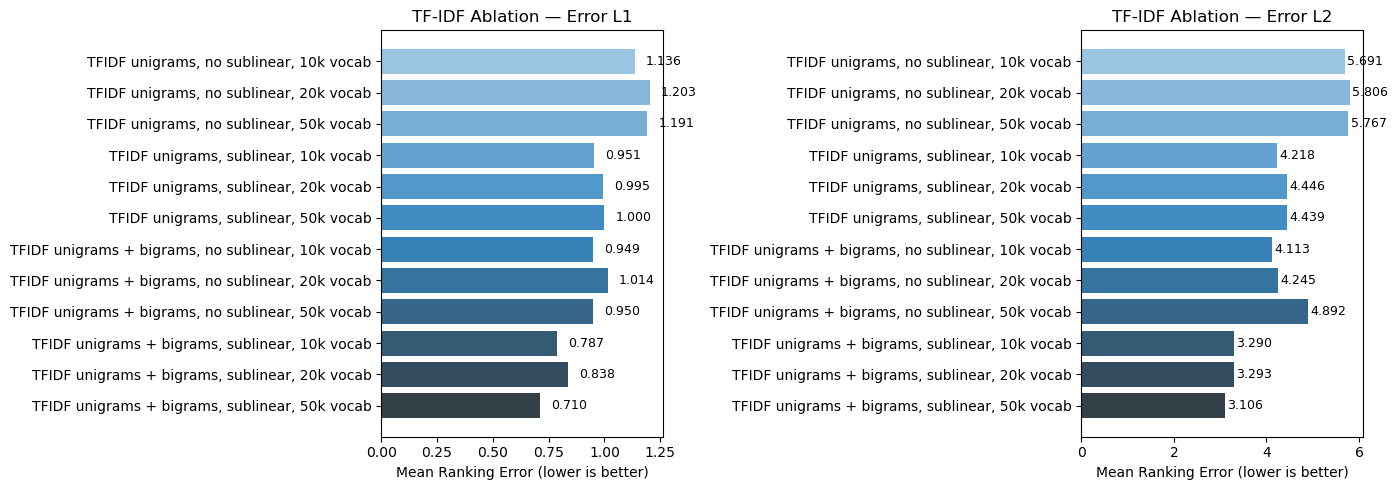

In [30]:
# Ablation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("Blues_d", len(result_dataset))

for ax, metric in zip(axes, ["Error L1", "Error L2"]):
    bars = ax.barh(result_dataset["Config"], result_dataset[metric], color=colors)
    ax.set_xlabel("Mean Ranking Error (lower is better)")
    ax.set_title(f"TF-IDF Ablation — {metric}")
    for bar, val in zip(bars, result_dataset[metric]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

We can see that the **best parameters** are:
- unigrams + biagrams
- sublinear
- 50k vocab

## 10. Model 3: Sentence Transformers (Dense Retrieval)

- We decided to test a third model: a dense retrieval approach using the `all-MiniLM-L6-v2` sentence transformer model (with 384-dimension embeddings) from Hugging Face.

- Since this model has a **maximum sequence length of 256 tokens** and our dataset for each place contains a concatenation of up to 50 reviews, encoding the full concatenated document would silently truncate most of the content. This would result in our model seeing only the beginning of the first reviews in the dataset.

- Our strategy to fix this: we **encode each review individually**, then **average the embeddings** per place. This preserves information from all reviews and produces a single dense vector per place. This way each review is fully encoded, and the model uses all the reviews.

In [33]:
# Loading Sentence-Transformer model
st_model = SentenceTransformer("all-MiniLM-L6-v2")

def compute_place_embeddings(dataset: pd.DataFrame, reviews_df: pd.DataFrame, max_reviews=50) -> np.ndarray:
    """
    For each place, encode individual reviews and average the embeddings.
    This avoids truncation and captures the full breadth of reviews.
    """
    embeddings = []

    # We loop through every place in the dataset
    for place_id in tqdm(dataset["place_id"], desc="Encoding places"):
        
        # Create a list of all the reviews for this place and we keep only the max_reviews first reviews
        place_reviews = reviews_df[reviews_df["idplace"] == place_id]["clean_review"].tolist()
        place_reviews = place_reviews[:max_reviews]

        # If there is no review for this place, we put a zero vector as embedding
        if not place_reviews:
            embeddings.append(np.zeros(384))
            continue

        # Encoding of the review
        review_embs = st_model.encode(
            place_reviews, batch_size=64, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )

        # Average of the embeddings
        avg_emb = review_embs.mean(axis=0)

        # Normalisation of the average
        avg_emb = avg_emb / (np.linalg.norm(avg_emb) + 1e-10)

        # We add the resulting embeddings to our list
        embeddings.append(avg_emb)

    # We return an array with all the average embeddings
    return np.array(embeddings)


print("Encoding test candidates")
test_embeddings = compute_place_embeddings(test_data, reviews_english, MAX_REVIEWS_PER_PLACE)

print("Encoding train queries")
train_embeddings = compute_place_embeddings(train_data, reviews_english, MAX_REVIEWS_PER_PLACE)

print(f"Embedding shapes — train: {train_embeddings.shape} | test: {test_embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding test candidates


Encoding places: 100%|██████████| 918/918 [00:47<00:00, 19.52it/s]


Encoding train queries


Encoding places: 100%|██████████| 917/917 [00:51<00:00, 17.70it/s]

Embedding shapes — train: (917, 384) | test: (918, 384)


In [38]:
# Compute dense rankings via dot product (embeddings are unit-normed)
BATCH_SIZE = 200
st_rankings_list = []

# We loop through the train embeddings in batch to compute the cosine similarity with all the test embeddings and get the rankings
for i in tqdm(range(0, len(train_embeddings), BATCH_SIZE), desc="ST ranking"):
    batch = train_embeddings[i : i + BATCH_SIZE]
    sims  = batch @ test_embeddings.T
    
    # We sort the rank in desending order
    ranked = np.argsort(sims, axis=1)[:, ::-1]
    st_rankings_list.append(ranked)

# We concatenate the rankings of all the batches to get the final rankings for all the train queries
st_rankings = np.vstack(st_rankings_list)
st_result = evaluate_model("Sentence-Transformers (per-review avg)", st_rankings)

ST ranking: 100%|██████████| 5/5 [00:00<00:00, 88.41it/s]


  Sentence-Transformers (per-review avg)
  Level 1:
  Evaluated: 917 queries | Undefined: 0 | Mean Error: 1.2257
  Level 2:
  Evaluated: 417 queries | Undefined: 500 | Mean Error: 5.6930


## 11. Fusion & Ensemble Models

Sparse (BM25, TF-IDF) and dense (Sentence-Transformers) models capture **complementary signals**: sparse methods excel at exact vocabulary overlap, while dense methods capture semantic similarity. We explore several combination strategies.

### Fusion Model: BM25 + TF-IDF Score Combination

BM25 and TF-IDF capture different aspects of text similarity:
So by combining their normalized scores, we can get another model

For each review, we:
1. Compute BM25 scores and TF-IDF cosine scores 
2. Min-max normalize both score vectors
3. We calculates the final according to this formula: `score = α × BM25_score + (1 - α) × TF-IDF_score`
4. We sweep α from 0.2 to 0.8 to find the optimal balance

In [26]:
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    """Min-max normalize a array"""
    min, max = scores.min(), scores.max()
    if max == min:
        return np.zeros_like(scores)
    return (scores - min) / (max - min)


# We pre-compute BM25 score matrix
bm25_score_matrix = np.zeros((len(train_data), len(test_data)))
for index in tqdm(range(len(train_data)), desc="BM25 scores"):
    bm25_score_matrix[index] = bm25_index.get_scores(train_data["reviews"].iloc[index].split())

# We pre-compute TF-IDF score matrix with our best parameters
tfidf_vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_vectorizer.fit(train_data["reviews"])
train_matrix = tfidf_vectorizer.transform(train_data["reviews"])  
test_matrix  = tfidf_vectorizer.transform(test_data["reviews"])   
tf_idf_score_matrix = (train_matrix @ test_matrix.T).toarray()  # (917, 918)

# Normalize both score
bm25_norm  = np.array([normalize_scores(row) for row in bm25_score_matrix])
tfidf_norm = np.array([normalize_scores(row) for row in tf_idf_score_matrix])


def get_fusion_rankings(alpha: float) -> np.ndarray:
    """
    Compute the rankings of the fusion model according to our formula
    """
    fused = alpha * bm25_norm + (1 - alpha) * tfidf_norm
    return np.argsort(fused, axis=1)[:, ::-1]


fusion_results = []
alphas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]

for alpha in alphas: # compute the score for every values of alpha
    rankings = get_fusion_rankings(alpha)
    l1_score = ranking_error_L1(train_data, test_data, rankings)
    l2_score = ranking_error_L2(train_data, test_data, rankings)
    fusion_results.append({
        "Model": f"Fusion ({alpha} × BM25_score + (1 - {alpha}) × TF-IDF_score)",
        "Error L1": round(l1_score, 4),
        "Error L2": round(l2_score, 4),
    })

# To free memory we delete the matrix
del train_matrix
del test_matrix
del tf_idf_score_matrix 
del bm25_score_matrix
gc.collect()

fusion_df = pd.DataFrame(fusion_results)

L1 eval: 100%|██████████| 917/917 [00:00<00:00, 6461.21it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.6859


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 8947.61it/s]


  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.1511


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 6505.37it/s]


...

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.9760


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 7071.36it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8190


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 11401.32it/s]


  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 4.5731


We show the result of our fusion model

In [27]:
fusion_df

,Model,Error L1,Error L2
0,Fusion (0.2 × BM25_score + (1 - 0.2) × TF-IDF_...,0.6859,3.1511
1,Fusion (0.3 × BM25_score + (1 - 0.3) × TF-IDF_...,0.7045,3.2662
2,Fusion (0.4 × BM25_score + (1 - 0.4) × TF-IDF_...,0.7350,3.4652
3,Fusion (0.5 × BM25_score + (1 - 0.5) × TF-IDF_...,0.7841,3.7578
4,Fusion (0.6 × BM25_score + (1 - 0.6) × TF-IDF_...,0.7983,3.9760
5,Fusion (0.8 × BM25_score + (1 - 0.8) × TF-IDF_...,0.8190,4.5731


## 12. Final Comparison

We display our best model with both evaluation metrics

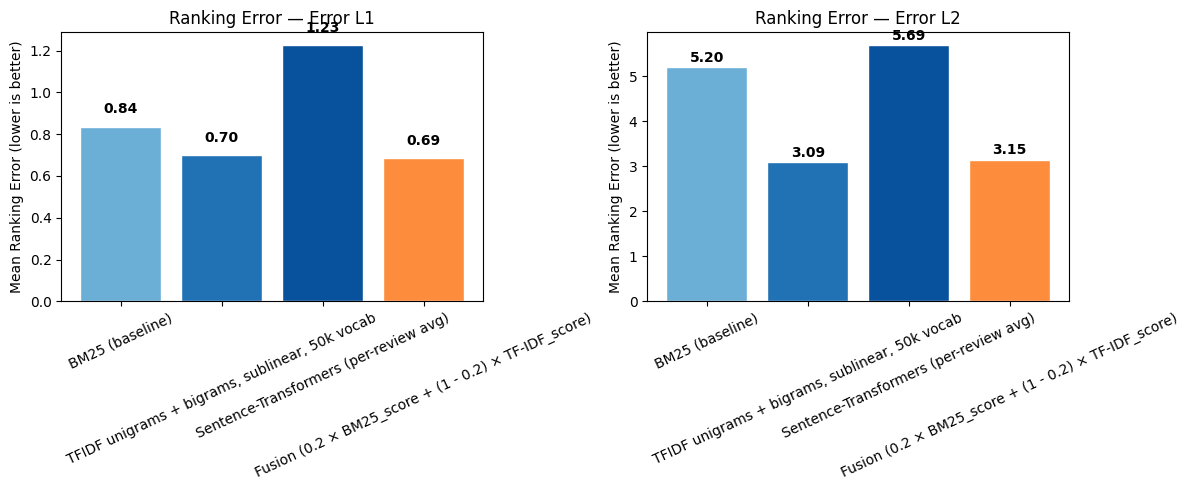

In [34]:
# Collect the best fusion result
best_fusion = min(fusion_results, key=lambda x: x["Error L2"])
best_TFIDF = min(result_dataset.to_dict('records'), key=lambda x: x["Error L2"])

final_results = pd.DataFrame([
    {"Model": "BM25 (baseline)","Error L1": round(bm25_L1, 4),  "Error L2": round(bm25_L2, 4)},
    best_TFIDF,
    {"Model": "Sentence-Transformers (per-review avg)","Error L1": round(st_L1, 4),    "Error L2": round(st_L2, 4)},
    best_fusion,
])

final_results.head(4)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#6baed6", "#2171b5", "#08519c", "#fd8d3c"]

for ax, metric in zip(axes, ["Error L1", "Error L2"]):
    bars = ax.bar(final_results["Model"], final_results[metric], color=colors, edgecolor="white")
    ax.set_ylabel("Mean Ranking Error (lower is better)")
    ax.set_title(f"Ranking Error — {metric}")
    ax.tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, final_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### Conclusion

## 11. Best Model Pipeline

Know that we know which model is the best, we can create our pipeline with this model

In [ ]:
class Review_model:
    def __init__(self, data_path):
        self.data_path = data_path
        
        self.vectorizer = None
        self.train_embeddings = None
        self.train_df = None

        
        self.max_features = 50_000
        self.ngram_range = (1, 2)
        self.sublinear = True


                    ### Preprocessing function

    def clean_text_spacy(self, texts: list) -> list:
        """
        Lemmatization of a batch of texts using spaCy.
        """
        results = []
        # We use pip to disable the parser and ner module of our spacy model so that our code run faster
        for doc in nlp.pipe(texts, batch_size=256, disable=["parser", "ner"]):
            # We apply lemmatisation and keeps only alphabetic, non-stop tokens longer than 2 characters
            lemmas = [
                t.lemma_.lower()
                for t in doc
                if t.is_alpha and not t.is_stop and len(t) > 2
            ]
            # We put the text together again to have our review
            results.append(" ".join(lemmas))
        return results
    
    def aggregate_reviews(self, reviews):
        """
        Transform the pandas series into a list and only keep at most 50 reviews
        """
        reviews_texts = reviews["clean_review"].tolist()
        if MAX_REVIEWS_PER_PLACE:
            reviews_texts = reviews_texts[:MAX_REVIEWS_PER_PLACE]
        # Create one string containing the list of reviews
        return " ".join(reviews_texts)
    
    def preprocessing(self, reviews_dataset,metadata_dataset = None):
        reviews_dataset["clean_review"] = self.clean_text_spacy(reviews_dataset["review"].tolist())
        reviews_place = (
            reviews_dataset
            .groupby("idplace", group_keys=False)
            .apply(self.aggregate_reviews, include_groups=False)
            .reset_index()
            .rename(columns={"idplace": "place_id", 0: "reviews"})
            )
        
        if metadata_dataset is None:
            # When we don't have a label(For prediction)
            return reviews_place
        metadata_colums = [column for column in META_COLS if column in metadata_dataset.columns]

        # We get our evaluation column into our model dataset
        reviews_place = reviews_place.merge(
            metadata_dataset[metadata_colums].rename(columns={"id": "place_id"}),
            on="place_id",
            how="left",
            )
        return reviews_place

        
                        ### Model function function


    def get_ranked_indices_batch(self, train_matrix, test_matrix, batch_size: int = 200) -> np.ndarray:
        """
        Function that compute the cosine similarity for every values in the test matrix 
        compared to the train matrix
        Processes in batches
        """
        n_train  = train_matrix.shape[0]
        all_rank = []

    # We use the tqdm function to create a display of the process
    # The loop works in batch 
        for i in tqdm(range(0, n_train, batch_size), desc="Cosine Simularities Ranking"):
            # We calculate the batch that we will treat in this loop
            batch      = train_matrix[i : i + batch_size]
            # We calculate the cosine similarity
            sims_batch = (batch @ test_matrix.T).toarray()   # (batch, n_candidates)
            # We sort the rank in desending order
            rank       = np.argsort(sims_batch, axis=1)[:, ::-1] 
            all_rank.append(rank)

        # Make a vertical fusion of all value that are in all_rank
        return np.vstack(all_rank)
    
    def fit(self, train_data):
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=self.max_features, 
            ngram_range=self.ngram_range, 
            sublinear_tf=self.sublinear_tf
            )

        self.tfidf_vectorizer.fit(train_data["reviews"])
        self.train_embeddings = self.vectorizer.transform(train_data["reviews"])  

    def transform(self, data):
        test_matrix  = self.vectorizer.transform(data["reviews"])   
        tfidf_rankings = self.get_ranked_indices_batch(self.train_embeddings, test_matrix)

        return tfidf_rankings
    
    def train(self, reviews_dataset,metadata_dataset):
        self.train_df = self.preprocessing(reviews_dataset,metadata_dataset)
        self.fit(self.train_df)

    def predict_rank(self, reviews_dataset):
        review_place = self.preprocessing(reviews_dataset)
        ranking = self.transform(review_place)
        return ranking
    

    
